# YouTube Insights Visualization

This notebook contains visualizations for 20 key insights from the YouTube dataset.

In [57]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# Set style for better-looking plots
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

# Set random seed for reproducibility
np.random.seed(42)

# Folder for static PNG outputs
FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Load the dataset
file_path = "../data/Global_YouTube_Statistics_Cleaned.csv"
df = pd.read_csv(file_path, encoding="latin-1")

df.head()

,ï»¿rank,youtuber,subscribers,video_views,category,title,uploads,country_of_origin,country,abbreviation,...,subscribers_for_last_30_days,created_year,created_month,created_date,gross_tertiary_education_enrollment_(%),population,unemployment_rate,urban_population,latitude,longitude
0,1,T-Series,245000000.0,2.280000e+11,Music,T-Series,20082,India,india,IN,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,3,MrBeast,166000000.0,2.836884e+10,Entertainment,MrBeast,741,United States,United States,US,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,4,Cocomelon - Nursery Rhymes,162000000.0,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,United States,US,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,5,SET India,159000000.0,1.480000e+11,Shows,SET India,116536,India,India,IN,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
4,7,Kids Diana Show,112000000.0,9.324704e+10,People & Blogs,Kids Diana Show,1111,United States,United States,US,...,0.0,2015.0,May,12.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891


## Data Preparation

Before we begin with the visualizations, let's check the data and prepare it for analysis.

In [58]:
# Quick schema + missingness overview
summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
    }
).sort_values(["missing", "missing_pct"], ascending=False)

summary.head(25)

,dtype,missing,missing_pct
gross_tertiary_education_enrollment_(%),float64,96,10.17
population,float64,96,10.17
unemployment_rate,float64,96,10.17
urban_population,float64,96,10.17
latitude,float64,96,10.17
longitude,float64,96,10.17
ï»¿rank,int64,0,0.00
youtuber,str,0,0.00
subscribers,float64,0,0.00
video_views,float64,0,0.00


In [59]:
# Check for missing values (top 25)
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0].head(25)

gross_tertiary_education_enrollment_(%)    96
latitude                                   96
longitude                                  96
urban_population                           96
unemployment_rate                          96
population                                 96
dtype: int64

# Insight 1: Negara dengan Channel YouTube Terbanyak (Countries with Most YouTube Channels)

**Variables:** Country, Youtuber
**Tools:** Microsoft Excel
**Method:** Using Pivot Table to calculate the number of channels by country
**Chart:** Bar Chart

## Why it's interesting

It's interesting because it shows which country dominates the YouTube platform.

## Interpretation

The United States and India have the largest number of channels, indicating a very large development of the digital creator industry in these two countries.

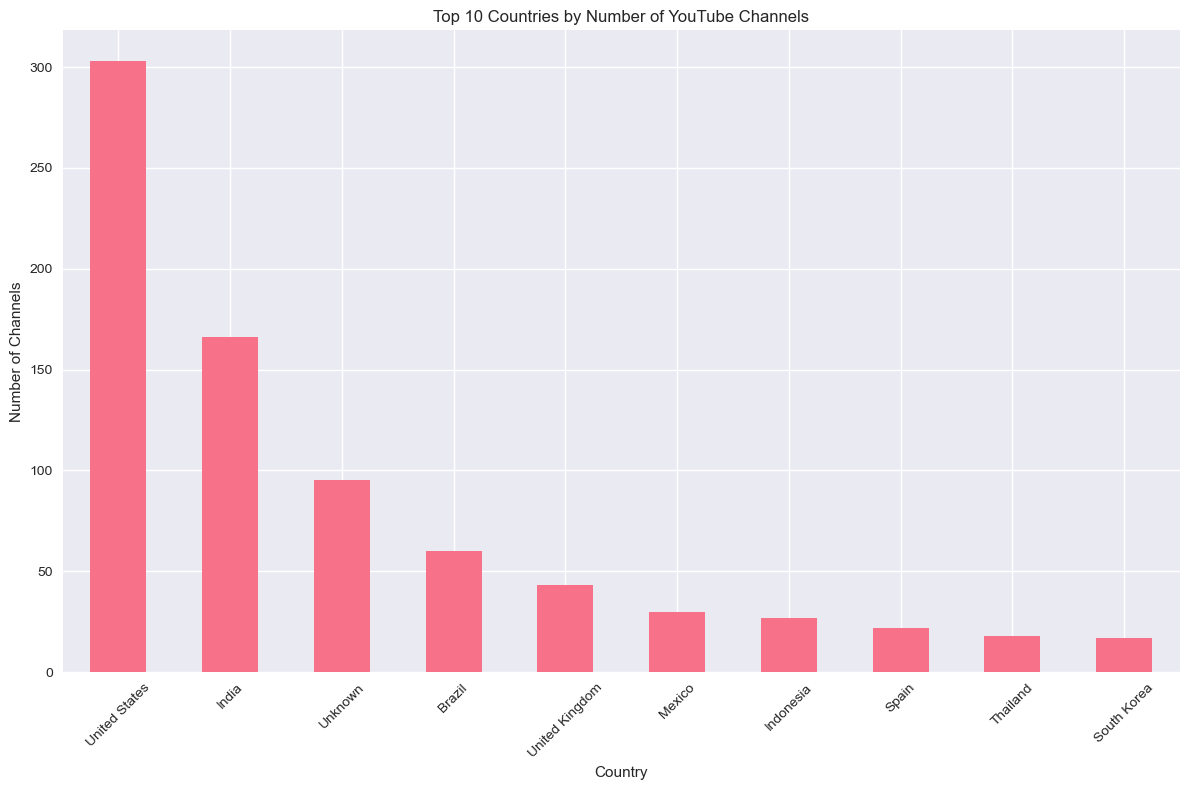

country
United States     303
India             166
Unknown            95
Brazil             60
United Kingdom     43
Mexico             30
Indonesia          27
Spain              22
Thailand           18
South Korea        17
dtype: int64

In [60]:
# Count the number of channels by country
country_counts = df.groupby("country").size().sort_values(ascending=False)

# Create a bar chart
plt.figure(figsize=(12, 8))
country_counts.head(10).plot(kind="bar")
plt.title("Top 10 Countries by Number of YouTube Channels")
plt.xlabel("Country")
plt.ylabel("Number of Channels")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "insight_01_countries_most_channels.png", dpi=300, bbox_inches="tight")
plt.show()

country_counts.head(10)

# Insight 2: Kategori Channel Paling Populer (Most Popular Channel Categories)

**Variables:** category
**Tools:** Microsoft Excel
**Method:** Counting the number of channels in each category
**Chart:** Pie Chart

## Why it's interesting

To find out what type of content is most popular with YouTube users.

## Interpretation

The entertainment and music categories are the most commonly found in large YouTube channels.

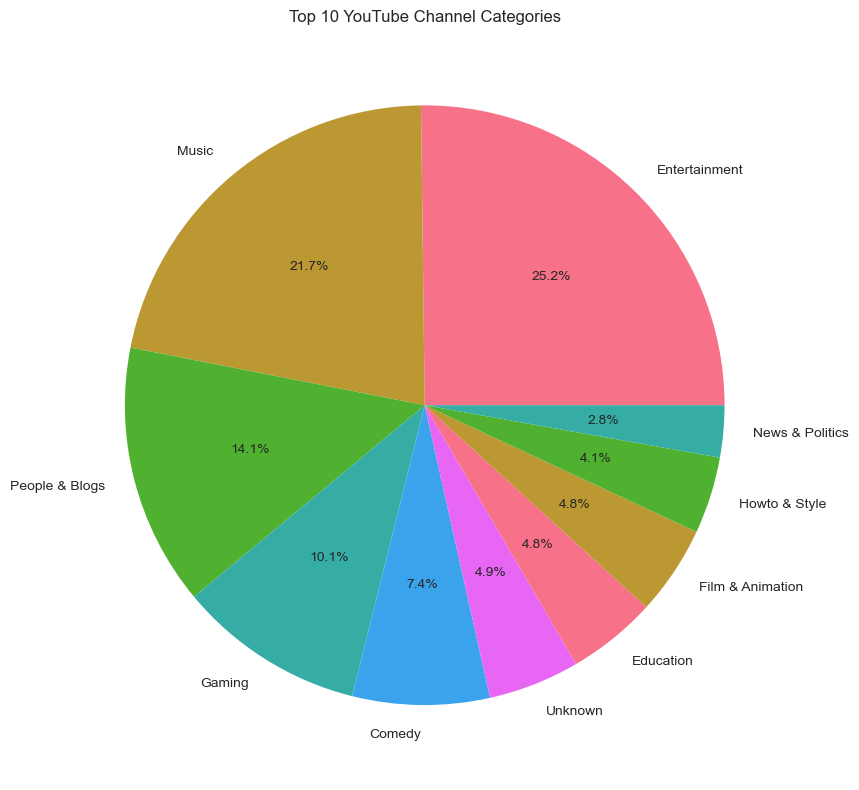

category
Entertainment       225
Music               194
People & Blogs      126
Gaming               90
Comedy               66
Unknown              44
Education            43
Film & Animation     43
Howto & Style        37
News & Politics      25
Name: count, dtype: int64

In [61]:
# Count the number of channels in each category
category_counts = df["category"].value_counts()

# Create a pie chart
plt.figure(figsize=(10, 8))
category_counts.head(10).plot(kind="pie", autopct="%1.1f%%")
plt.title("Top 10 YouTube Channel Categories")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "insight_02_top_categories_pie.png", dpi=300, bbox_inches="tight")
plt.show()

category_counts.head(10)

# Insight 3: Top 10 Channel dengan Subscriber Terbanyak (Top 10 Channels with Most Subscribers)

**Variables:** Youtuber, subscribers
**Tools:** Microsoft Excel
**Method:** Sorting descending based on subscriber count
**Chart:** Horizontal Bar Chart

## Why it's interesting

It's interesting because it shows the most popular channels in the world.

## Interpretation

Channels with the highest subscribers have great influence on the platform.

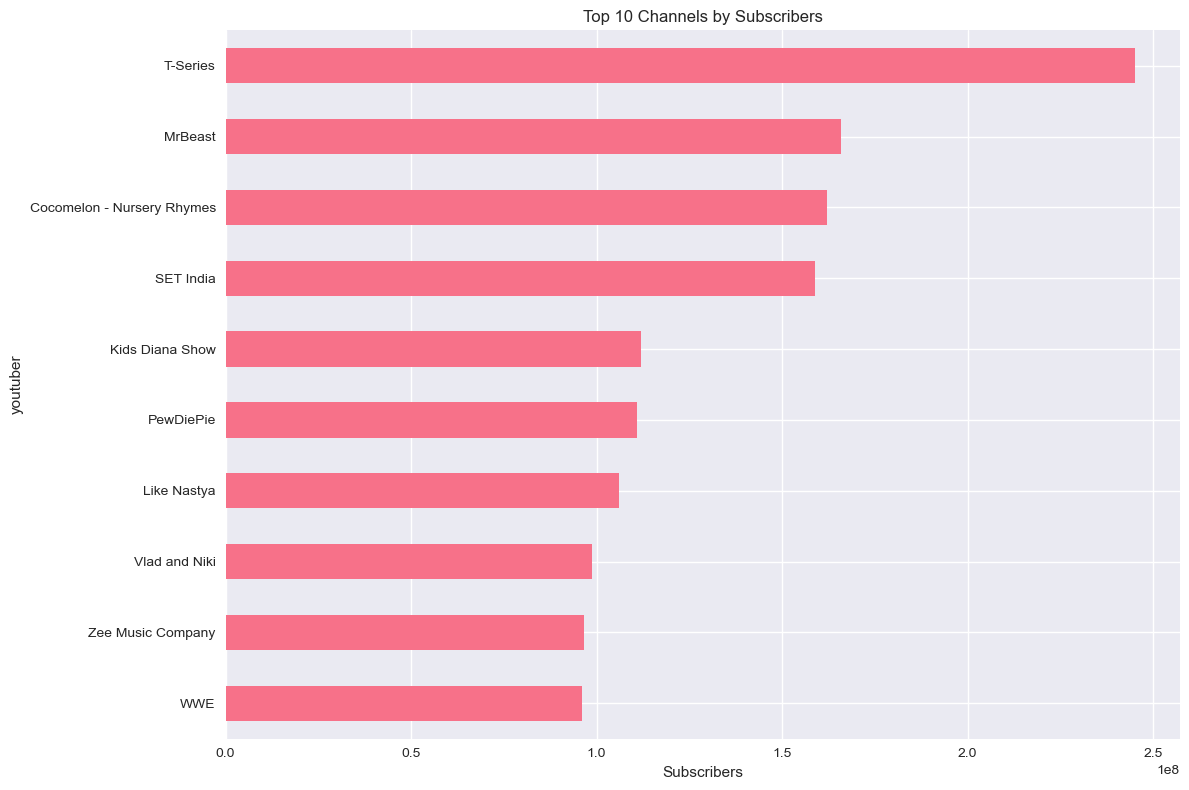

,youtuber,subscribers
9,WWE,96000000.0
8,Zee Music Company,96700000.0
7,Vlad and Niki,98900000.0
6,Like Nastya,106000000.0
5,PewDiePie,111000000.0
4,Kids Diana Show,112000000.0
3,SET India,159000000.0
2,Cocomelon - Nursery Rhymes,162000000.0
1,MrBeast,166000000.0
0,T-Series,245000000.0


In [62]:
# Horizontal bar chart: top 10 channels by subscribers
top_channels = (
    df[["youtuber", "subscribers"]]
    .sort_values("subscribers", ascending=False)
    .head(10)
    .sort_values("subscribers")
)

ax = top_channels.plot(kind="barh", x="youtuber", y="subscribers", figsize=(12, 8), legend=False)
ax.set_title("Top 10 Channels by Subscribers")
ax.set_xlabel("Subscribers")
plt.tight_layout()
plt.savefig(FIG_DIR / "insight_03_top10_subscribers_barh.png", dpi=300, bbox_inches="tight")
plt.show()

top_channels

# Insight 4: Hubungan Subscriber dengan Video Views (Relationship between Subscribers and Video Views)

**Variables:** subscribers, video views
**Tools:** Microsoft Excel
**Method:** Scatter plot and simple correlation
**Chart:** Scatter Plot

## Why it's interesting

To see if subscribers affect video views.

## Interpretation

Generally, channels with more subscribers have higher video views.

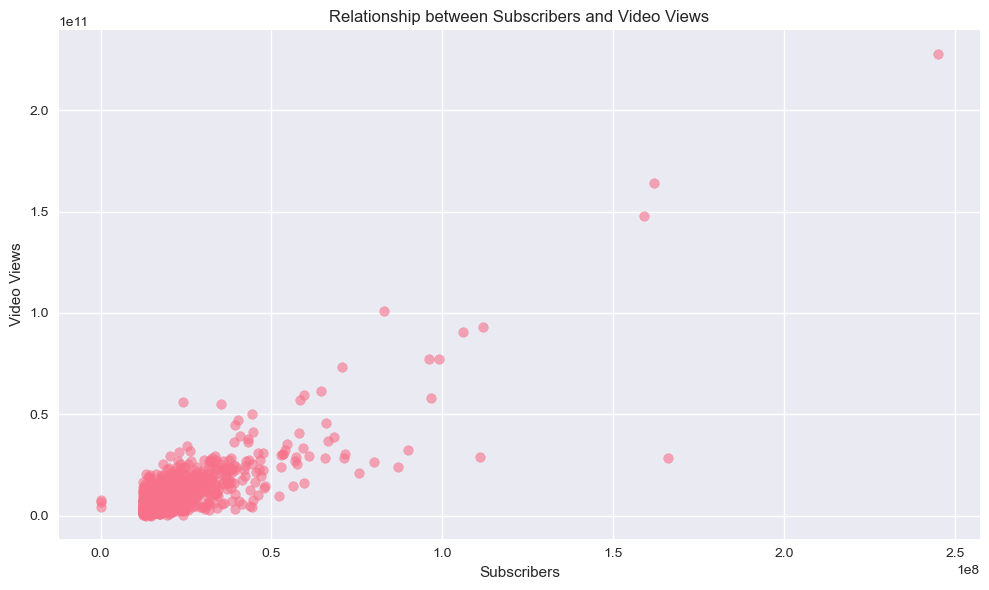

np.float64(0.8272544924920042)

In [63]:
# Scatter plot of subscribers vs video views
plt.figure(figsize=(10, 6))
plt.scatter(df["subscribers"], df["video_views"], alpha=0.6)
plt.title("Relationship between Subscribers and Video Views")
plt.xlabel("Subscribers")
plt.ylabel("Video Views")
plt.tight_layout()
plt.savefig(FIG_DIR / "insight_04_subscribers_vs_views_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

correlation = df["subscribers"].corr(df["video_views"])
correlation

# Insight 5: Pengaruh Jumlah Upload terhadap Subscriber (Influence of Upload Count on Subscribers)

**Variables:** uploads, subscribers
**Tools:** Microsoft Excel
**Method:** Comparison and scatter plot
**Chart:** Scatter Plot

## Why it's interesting

To see if many uploads cause higher subscribers.

## Interpretation

Not always; quality matters more.

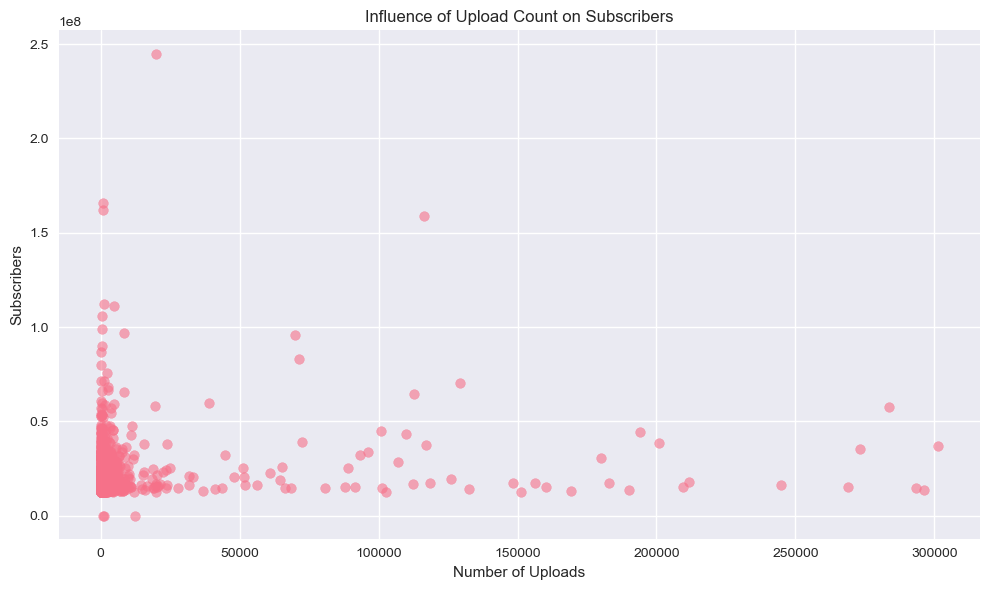

In [64]:
# Scatter plot of uploads vs subscribers
plt.figure(figsize=(10, 6))
plt.scatter(df["uploads"], df["subscribers"], alpha=0.6)
plt.title("Influence of Upload Count on Subscribers")
plt.xlabel("Number of Uploads")
plt.ylabel("Subscribers")
plt.tight_layout()
plt.savefig(FIG_DIR / "insight_05_uploads_vs_subscribers_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

# Insight 6: Channel dengan Penghasilan Tahunan Tertinggi (Channel with Highest Annual Earnings)

**Variables:** highest_yearly_earnings, Youtuber
**Tools:** Microsoft Excel
**Method:** Sorting descending by earnings
**Chart:** Bar Chart

## Why it's interesting

To show potential earnings.

## Interpretation

Some channels earn very high annual incomes.

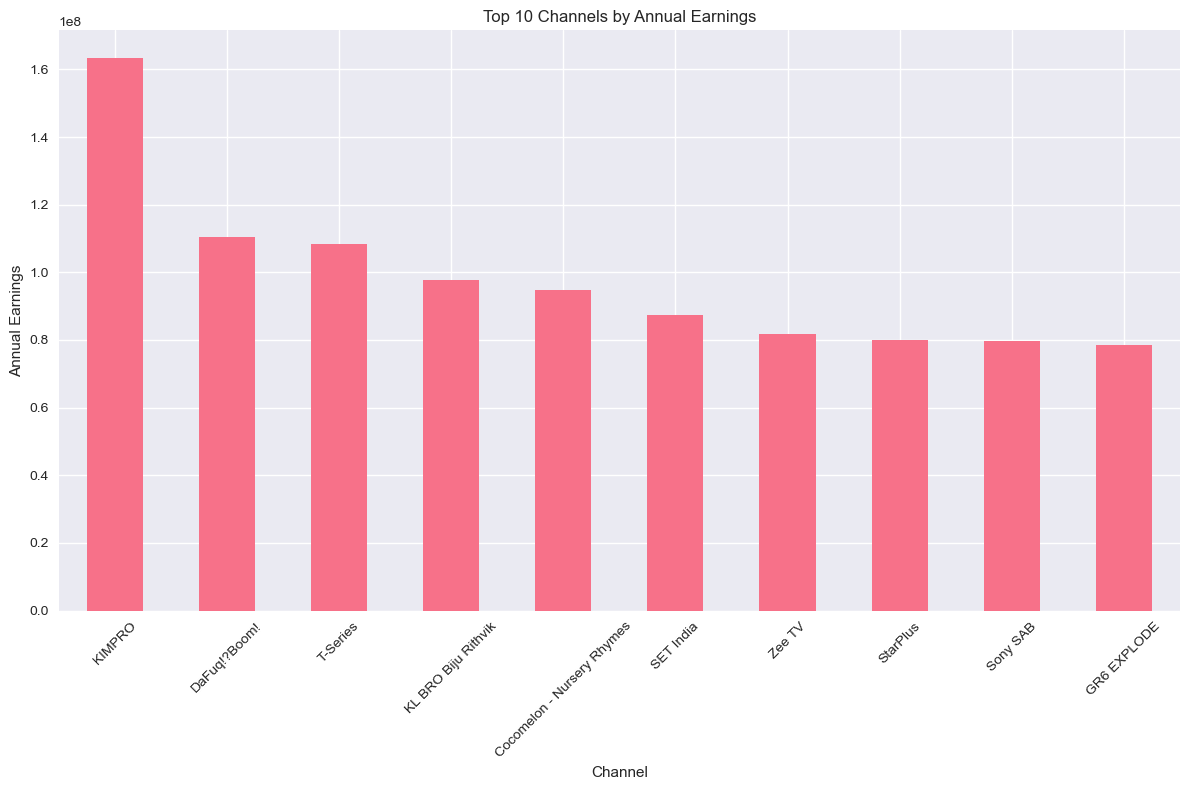

,youtuber,highest_yearly_earnings
465,KIMPRO,163400000.0
392,DaFuq!?Boom!,110600000.0
0,T-Series,108400000.0
282,KL BRO Biju Rithvik,97600000.0
2,Cocomelon - Nursery Rhymes,94800000.0
3,SET India,87500000.0
17,Zee TV,81900000.0
130,StarPlus,80000000.0
12,Sony SAB,79600000.0
77,GR6 EXPLODE,78500000.0


In [65]:
# Bar chart of top 10 channels by annual earnings
top_earnings = (
    df[["youtuber", "highest_yearly_earnings"]]
    .sort_values("highest_yearly_earnings", ascending=False)
    .head(10)
)

ax = top_earnings.plot(kind="bar", x="youtuber", y="highest_yearly_earnings", figsize=(12, 8), legend=False)
ax.set_title("Top 10 Channels by Annual Earnings")
ax.set_xlabel("Channel")
ax.set_ylabel("Annual Earnings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "insight_06_top10_annual_earnings_bar.png", dpi=300, bbox_inches="tight")
plt.show()

top_earnings

# Insight 7: Negara dengan Total Subscriber Terbesar (Country with Total Largest Subscribers)

**Variables:** Country, subscribers
**Tools:** Microsoft Excel
**Method:** SUM subscribers by country
**Chart:** Bar Chart

## Why it's interesting

To see countries with largest subscriber influence.

## Interpretation

India and the United States dominate in total subscribers.

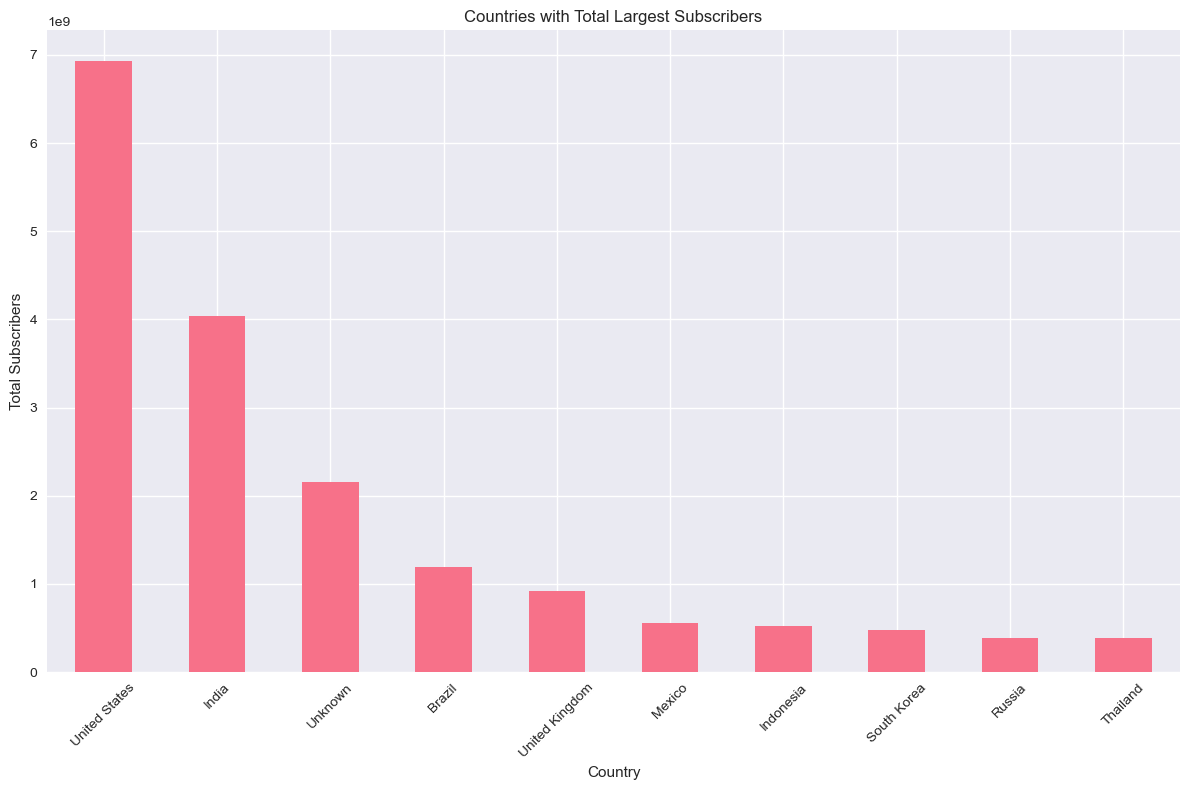

country
United States     6.932300e+09
India             4.039800e+09
Unknown           2.157700e+09
Brazil            1.188800e+09
United Kingdom    9.174000e+08
Mexico            5.536000e+08
Indonesia         5.211000e+08
South Korea       4.817000e+08
Russia            3.913000e+08
Thailand          3.865000e+08
Name: subscribers, dtype: float64

In [66]:
# Sum subscribers by country
country_subs = df.groupby("country")["subscribers"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
country_subs.head(10).plot(kind="bar")
plt.title("Countries with Total Largest Subscribers")
plt.xlabel("Country")
plt.ylabel("Total Subscribers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "insight_07_total_subscribers_by_country_bar.png", dpi=300, bbox_inches="tight")
plt.show()

country_subs.head(10)

# Insight 8: Rata-rata Views Berdasarkan Kategori (Average Views by Category)

**Variables:** category, video views
**Tools:** Microsoft Excel
**Method:** Calculate average views per category
**Chart:** Column Chart

## Why it's interesting

To see which category performs best.

## Interpretation

Music category has the highest average video views.

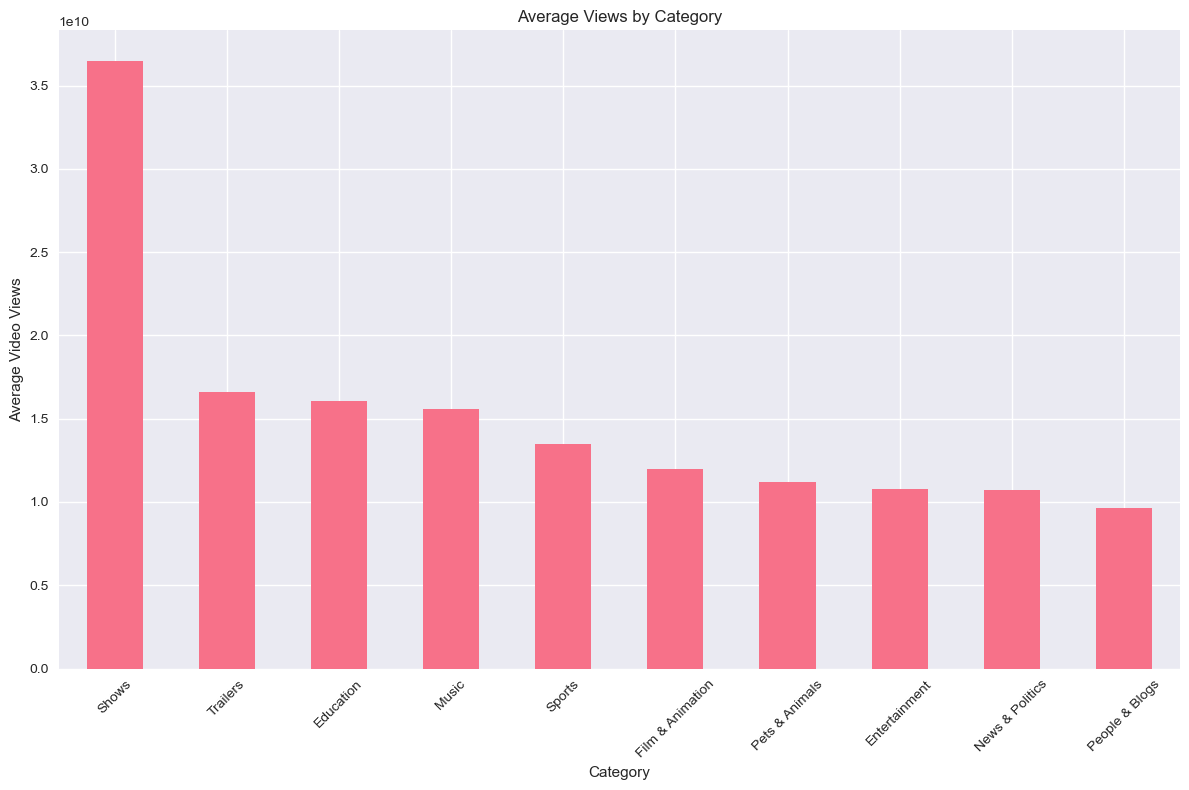

category
Shows               3.649209e+10
Trailers            1.663136e+10
Education           1.605794e+10
Music               1.558102e+10
Sports              1.345330e+10
Film & Animation    1.197498e+10
Pets & Animals      1.121669e+10
Entertainment       1.076427e+10
News & Politics     1.069525e+10
People & Blogs      9.612900e+09
Name: video_views, dtype: float64

In [67]:
# Compute average views by category
category_avg_views = df.groupby("category")["video_views"].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
category_avg_views.head(10).plot(kind="bar")
plt.title("Average Views by Category")
plt.xlabel("Category")
plt.ylabel("Average Video Views")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "insight_08_avg_views_by_category_bar.png", dpi=300, bbox_inches="tight")
plt.show()

category_avg_views.head(10)

# Insight 9: Pertumbuhan Subscriber dalam 30 Hari Terakhir (Subscriber Growth in Last 30 Days)

**Variables:** subscribers_for_last_30_days
**Tools:** Microsoft Excel
**Method:** Sorting descending
**Chart:** Bar Chart

## Why it's interesting

To show fast-growing channels.

## Interpretation

Viral channels experience high subscriber growth in a short period.

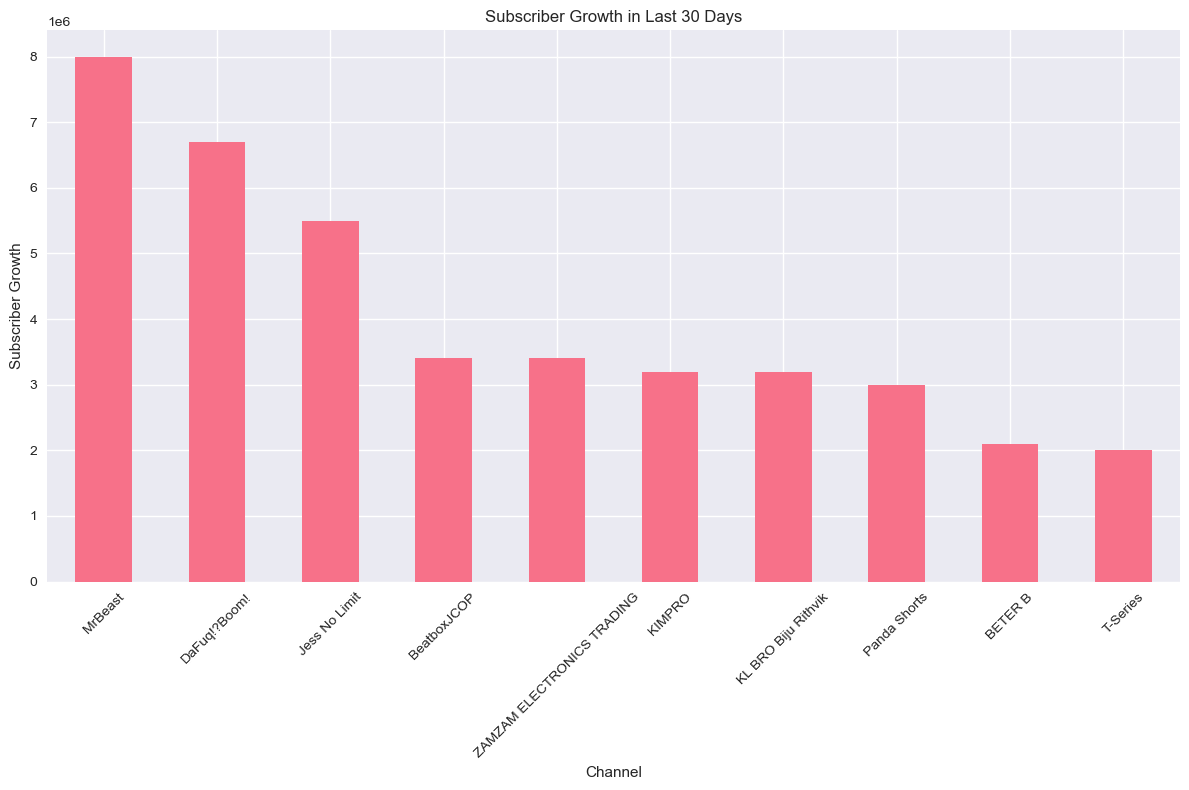

,youtuber,subscribers_for_last_30_days
1,MrBeast,8000000.0
392,DaFuq!?Boom!,6700000.0
108,Jess No Limit,5500000.0
453,BeatboxJCOP,3400000.0
312,ZAMZAM ELECTRONICS TRADING,3400000.0
465,KIMPRO,3200000.0
282,KL BRO Biju Rithvik,3200000.0
564,Panda Shorts,3000000.0
123,BETER B,2100000.0
0,T-Series,2000000.0


In [68]:
# Bar chart of subscriber growth in last 30 days
growth = (
    df[["youtuber", "subscribers_for_last_30_days"]]
    .sort_values("subscribers_for_last_30_days", ascending=False)
    .head(10)
)

ax = growth.plot(kind="bar", x="youtuber", y="subscribers_for_last_30_days", figsize=(12, 8), legend=False)
ax.set_title("Subscriber Growth in Last 30 Days")
ax.set_xlabel("Channel")
ax.set_ylabel("Subscriber Growth")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "insight_09_subscriber_growth_last30_bar.png", dpi=300, bbox_inches="tight")
plt.show()

growth

# Insight 10: Distribusi Jumlah Upload Video (Distribution of Video Upload Counts)

**Variables:** uploads
**Tools:** Microsoft Excel
**Method:** Histogram
**Chart:** Histogram

## Why it's interesting

To see upload habits of channels.

## Interpretation

Most channels have a medium number of uploads.

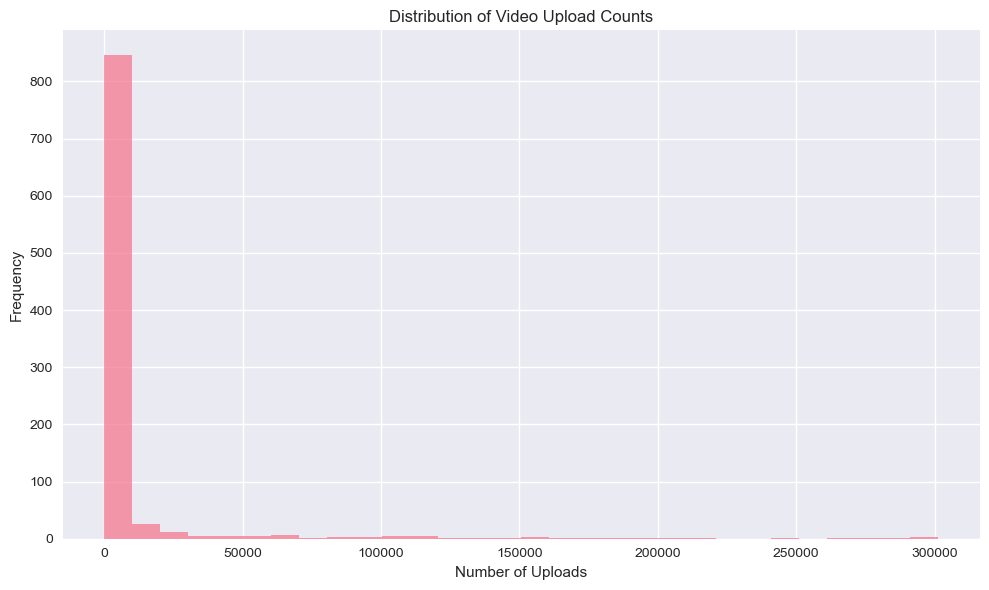

In [69]:
# Histogram of upload counts
plt.figure(figsize=(10, 6))
plt.hist(df["uploads"], bins=30, alpha=0.7)
plt.title("Distribution of Video Upload Counts")
plt.xlabel("Number of Uploads")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIG_DIR / "insight_10_uploads_distribution_hist.png", dpi=300, bbox_inches="tight")
plt.show()

# Insight 11: Tahun Pembuatan Channel dan Subscriber (Channel Creation Year and Subscribers)

**Variables:** created_year, subscribers
**Tools:** Microsoft Excel
**Method:** Scatter plot
**Chart:** Scatter Plot

## Why it's interesting

To see if older channels are more popular.

## Interpretation

Not necessarily; channel age does not guarantee higher subscribers.

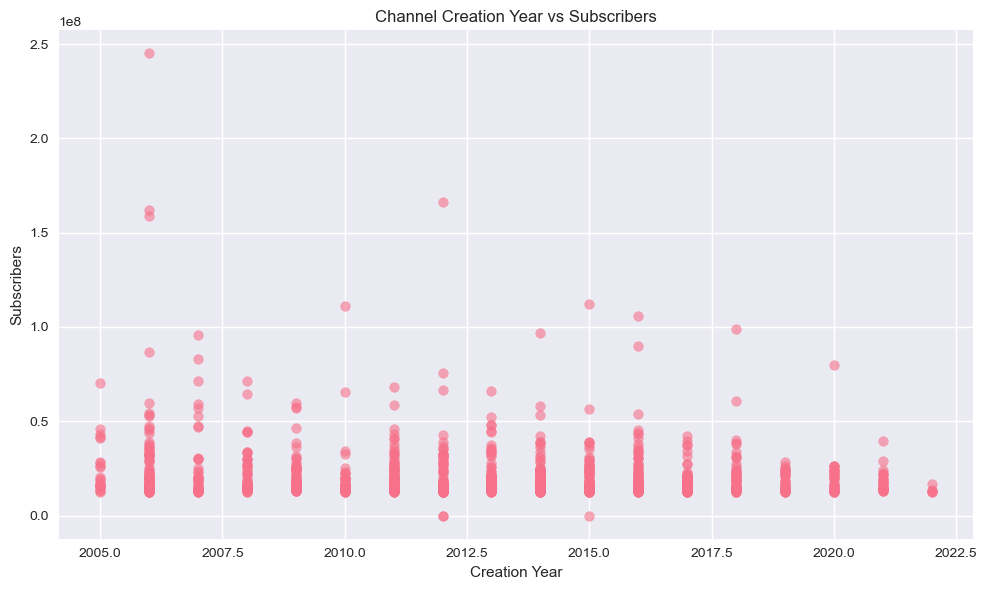

In [70]:
# Scatter plot of creation year vs subscribers
plt.figure(figsize=(10, 6))
plt.scatter(df["created_year"], df["subscribers"], alpha=0.6)
plt.title("Channel Creation Year vs Subscribers")
plt.xlabel("Creation Year")
plt.ylabel("Subscribers")
plt.tight_layout()
plt.savefig(FIG_DIR / "insight_11_created_year_vs_subscribers_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

# Insight 12: Jenis Channel yang Paling Dominan (Dominant Channel Type)

**Variables:** channel_type
**Tools:** Microsoft Excel
**Method:** Count per type
**Chart:** Pie Chart

## Why it's interesting

To see the content type that dominates YouTube.

## Interpretation

Entertainment channels are the most dominant type.

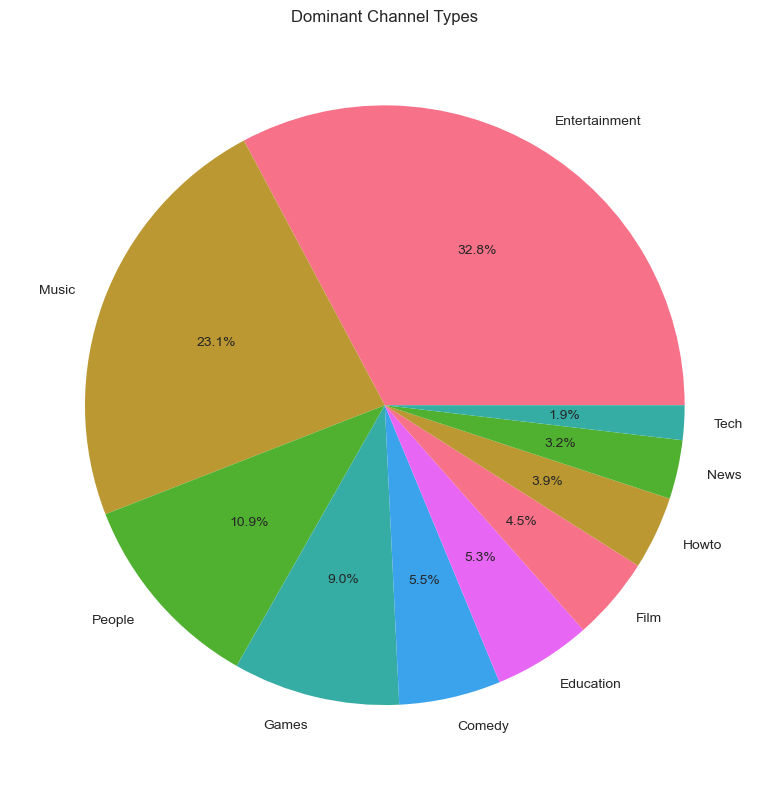

channel_type
Entertainment    299
Music            211
People            99
Games             82
Comedy            50
Education         48
Film              41
Howto             36
News              29
Tech              17
Name: count, dtype: int64

In [71]:
# Pie chart of channel types
channel_type_counts = df["channel_type"].value_counts()

plt.figure(figsize=(10, 8))
channel_type_counts.head(10).plot(kind="pie", autopct="%1.1f%%")
plt.title("Dominant Channel Types")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "insight_12_channel_types_pie.png", dpi=300, bbox_inches="tight")
plt.show()

channel_type_counts.head(10)

# Insight 13: Perbandingan Penghasilan Bulanan Channel (Comparison of Monthly Earnings)

**Variables:** highest_monthly_earnings, lowest_monthly_earnings
**Tools:** Microsoft Excel
**Method:** Comparison of earnings
**Chart:** Bar Chart

## Why it's interesting

To see the differences in earnings among channels.

## Interpretation

Earnings among YouTube channels vary greatly.

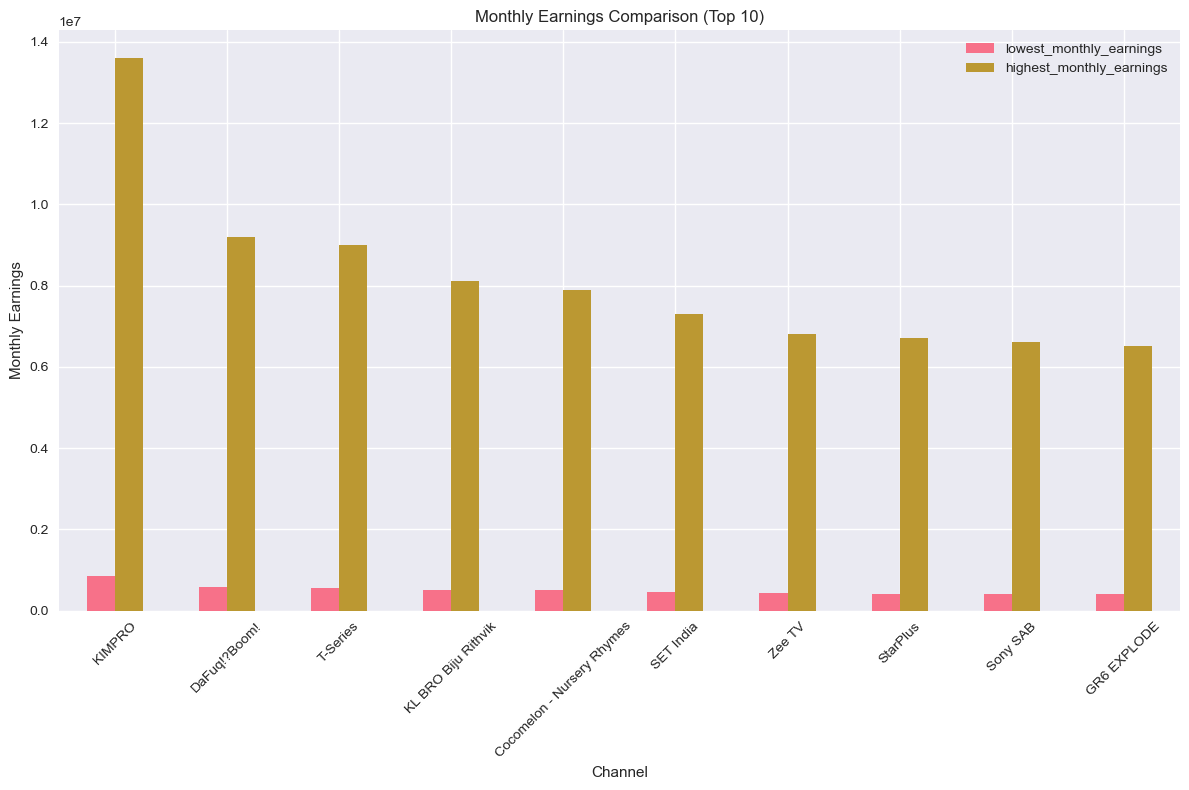

,youtuber,highest_monthly_earnings,lowest_monthly_earnings
465,KIMPRO,13600000.0,850900.0
392,DaFuq!?Boom!,9200000.0,576000.0
0,T-Series,9000000.0,564600.0
282,KL BRO Biju Rithvik,8100000.0,508100.0
2,Cocomelon - Nursery Rhymes,7900000.0,493800.0
3,SET India,7300000.0,455900.0
17,Zee TV,6800000.0,426800.0
130,StarPlus,6700000.0,416800.0
12,Sony SAB,6600000.0,414300.0
77,GR6 EXPLODE,6500000.0,408700.0


In [72]:
# Bar chart of monthly earnings comparison (top 10)
top_earnings = (
    df[["youtuber", "highest_monthly_earnings", "lowest_monthly_earnings"]]
    .sort_values("highest_monthly_earnings", ascending=False)
    .head(10)
)

ax = top_earnings.plot(kind="bar", x="youtuber", y=["lowest_monthly_earnings", "highest_monthly_earnings"], figsize=(12, 8))
ax.set_title("Monthly Earnings Comparison (Top 10)")
ax.set_xlabel("Channel")
ax.set_ylabel("Monthly Earnings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "insight_13_monthly_earnings_low_vs_high_bar.png", dpi=300, bbox_inches="tight")
plt.show()

top_earnings

# Insight 14: Channel dengan Video Views Terbesar (Channel with Most Video Views)

**Variables:** video views, Youtuber
**Tools:** Microsoft Excel
**Method:** Sorting by video views
**Chart:** Bar Chart

## Why it's interesting

To show the largest audience reach.

## Interpretation

Channels with high views have a wide reach to viewers.

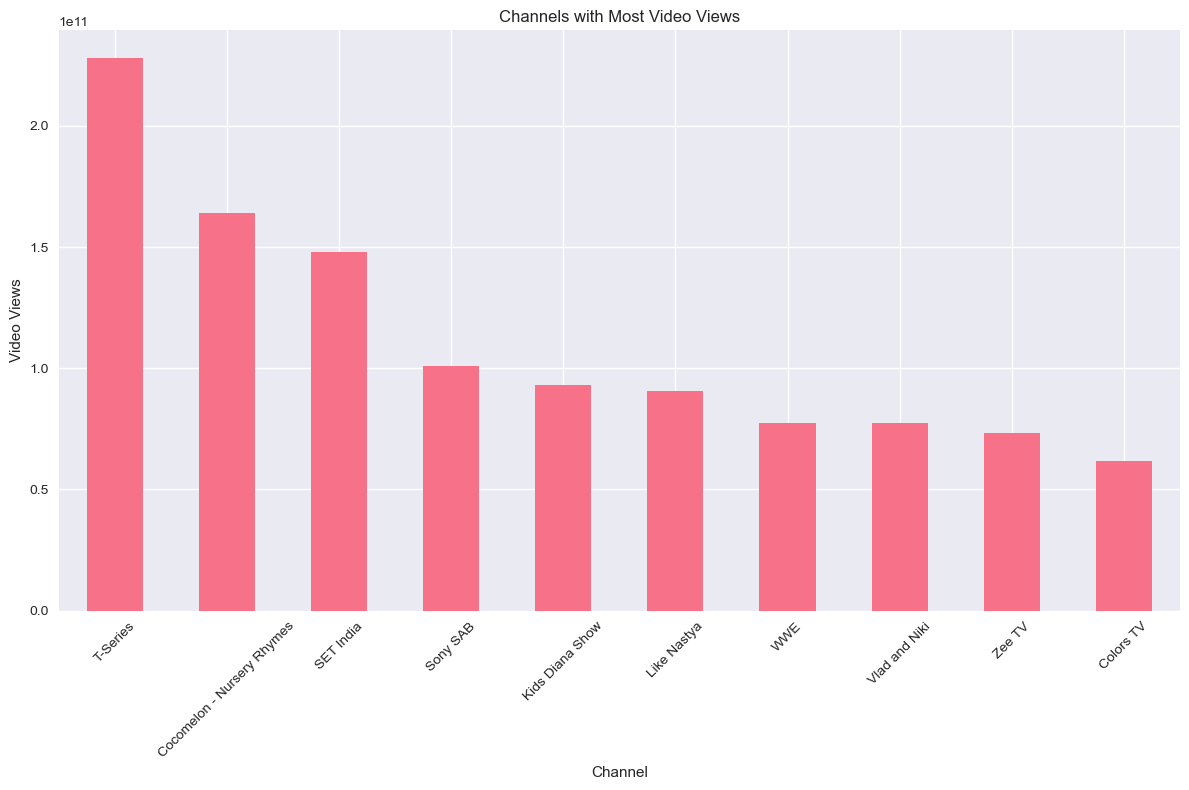

,youtuber,video_views
0,T-Series,2.280000e+11
2,Cocomelon - Nursery Rhymes,1.640000e+11
3,SET India,1.480000e+11
12,Sony SAB,1.010000e+11
4,Kids Diana Show,9.324704e+10
6,Like Nastya,9.047906e+10
9,WWE,7.742847e+10
7,Vlad and Niki,7.718017e+10
17,Zee TV,7.313905e+10
22,Colors TV,6.151091e+10


In [73]:
# Bar chart of channels with most video views
top_views = df[["youtuber", "video_views"]].sort_values("video_views", ascending=False).head(10)

ax = top_views.plot(kind="bar", x="youtuber", y="video_views", figsize=(12, 8), legend=False)
ax.set_title("Channels with Most Video Views")
ax.set_xlabel("Channel")
ax.set_ylabel("Video Views")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "insight_14_top10_video_views_bar.png", dpi=300, bbox_inches="tight")
plt.show()

top_views

# Insight 15: Upload Sedikit tetapi Subscriber Tinggi (Few Uploads but High Subscribers)

**Variables:** uploads, subscribers
**Tools:** Microsoft Excel
**Method:** Find extremes
**Chart:** Scatter Plot

## Why it's interesting

To examine quality vs quantity.

## Interpretation

Content quality can be more important than upload frequency.

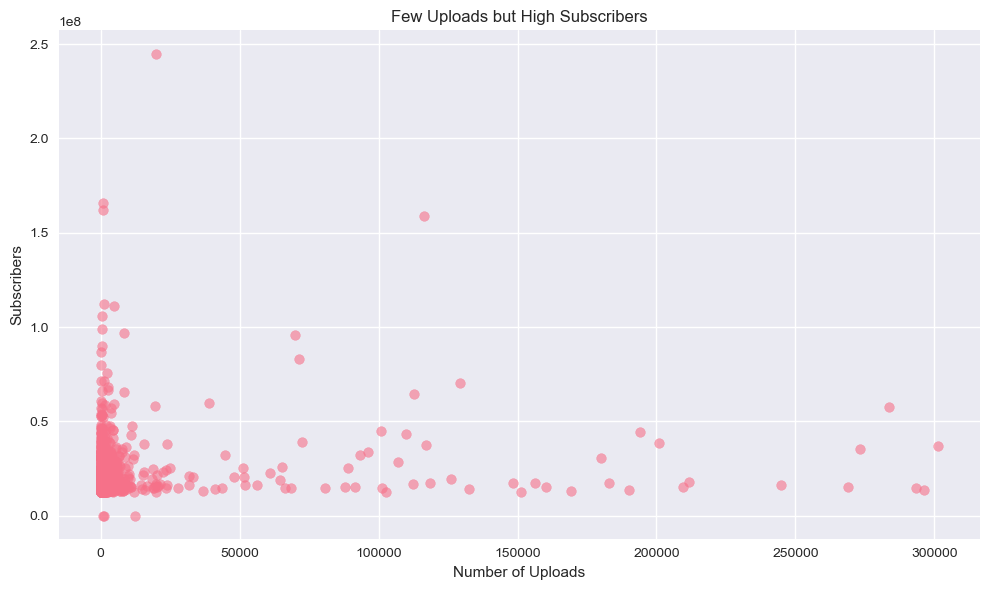

In [74]:
# Scatter plot of uploads vs subscribers
plt.figure(figsize=(10, 6))
plt.scatter(df["uploads"], df["subscribers"], alpha=0.6)
plt.title("Few Uploads but High Subscribers")
plt.xlabel("Number of Uploads")
plt.ylabel("Subscribers")
plt.tight_layout()
plt.savefig(FIG_DIR / "insight_15_few_uploads_high_subscribers_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

# Insight 16: Distribusi Tahun Pembuatan Channel (Distribution of Channel Creation Year)

**Variables:** created_year
**Tools:** Microsoft Excel
**Method:** Histogram
**Chart:** Histogram

## Why it's interesting

To see YouTube's growth over the years.

## Interpretation

Many large channels were created during the early years of YouTube.

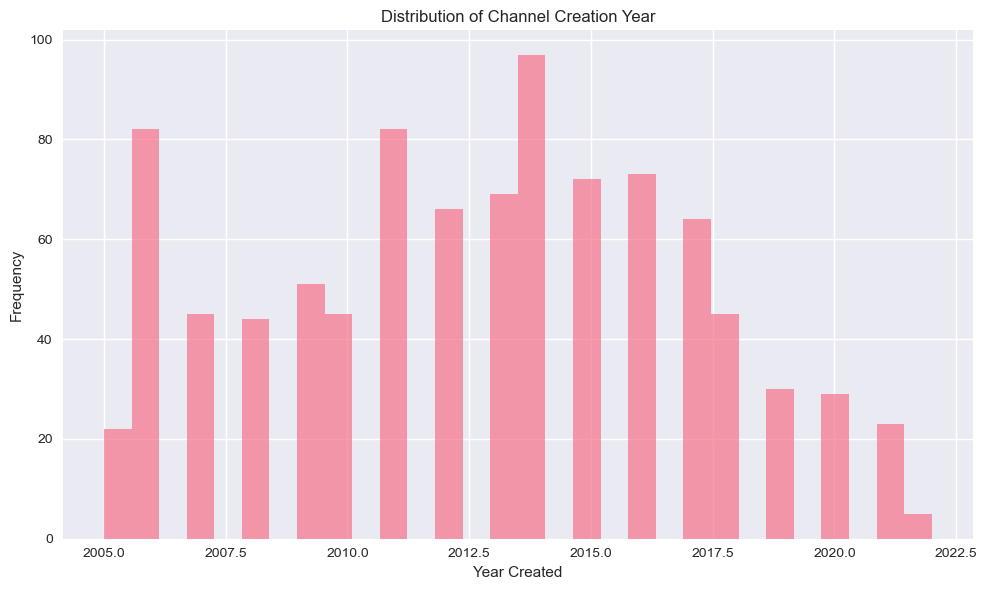

In [75]:
# Histogram of channel creation year
plt.figure(figsize=(10, 6))
plt.hist(df["created_year"], bins=30, alpha=0.7)
plt.title("Distribution of Channel Creation Year")
plt.xlabel("Year Created")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIG_DIR / "insight_16_created_year_distribution_hist.png", dpi=300, bbox_inches="tight")
plt.show()

# Insight 17: Pengaruh Kategori terhadap Penghasilan (Influence of Category on Earnings)

**Variables:** category, highest_yearly_earnings
**Tools:** Microsoft Excel
**Method:** Average earnings by category
**Chart:** Bar Chart

## Why it's interesting

To see which categories have the best monetization.

## Interpretation

Entertainment and music categories show high earning potential.

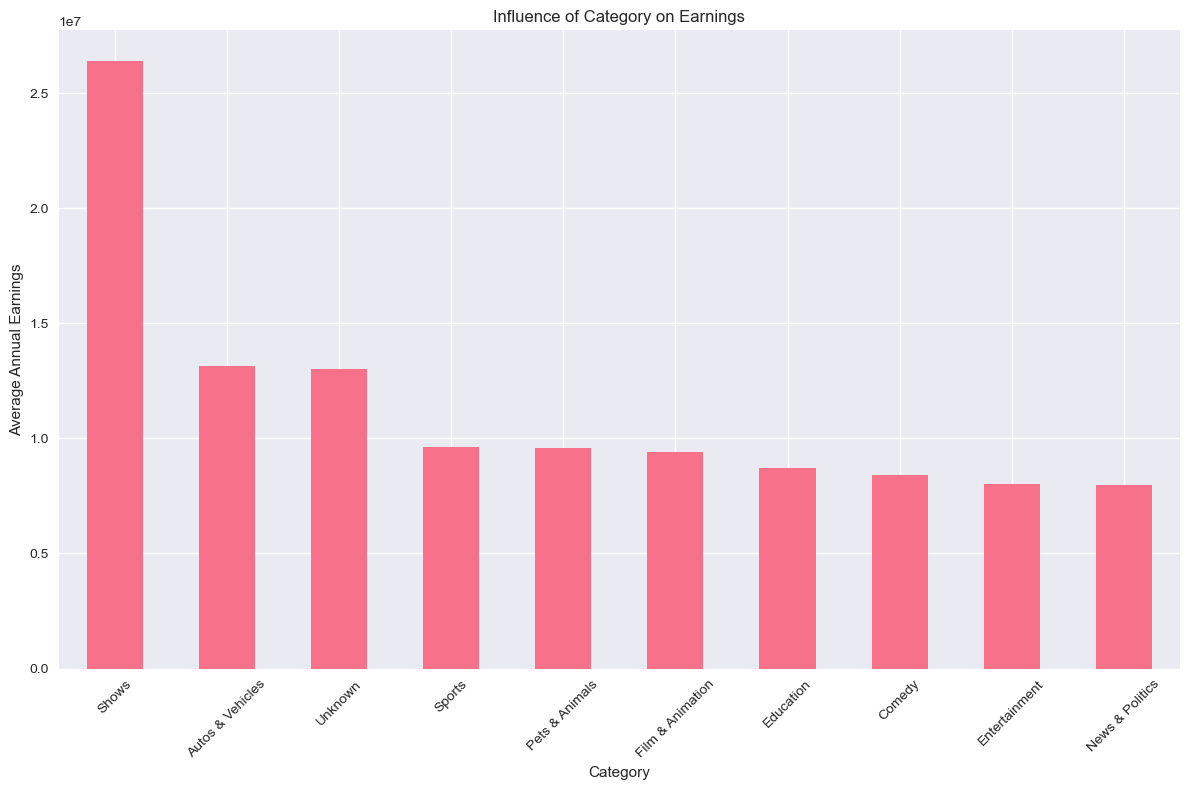

category
Shows               2.641667e+07
Autos & Vehicles    1.315000e+07
Unknown             1.302042e+07
Sports              9.615118e+06
Pets & Animals      9.575086e+06
Film & Animation    9.411365e+06
Education           8.711572e+06
Comedy              8.404015e+06
Entertainment       8.001933e+06
News & Politics     7.976063e+06
Name: highest_yearly_earnings, dtype: float64

In [76]:
# Bar chart of average earnings by category
category_earnings = df.groupby("category")["highest_yearly_earnings"].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
category_earnings.head(10).plot(kind="bar")
plt.title("Influence of Category on Earnings")
plt.xlabel("Category")
plt.ylabel("Average Annual Earnings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "insight_17_avg_annual_earnings_by_category_bar.png", dpi=300, bbox_inches="tight")
plt.show()

category_earnings.head(10)

# Insight 18: Video Views dalam 30 Hari Terakhir (Video Views in Last 30 Days)

**Variables:** video_views_for_the_last_30_days
**Tools:** Microsoft Excel
**Method:** Sorting and trend analysis
**Chart:** Line Chart

## Why it's interesting

To see trending channels.

## Interpretation

Views can spike rapidly due to viral content.

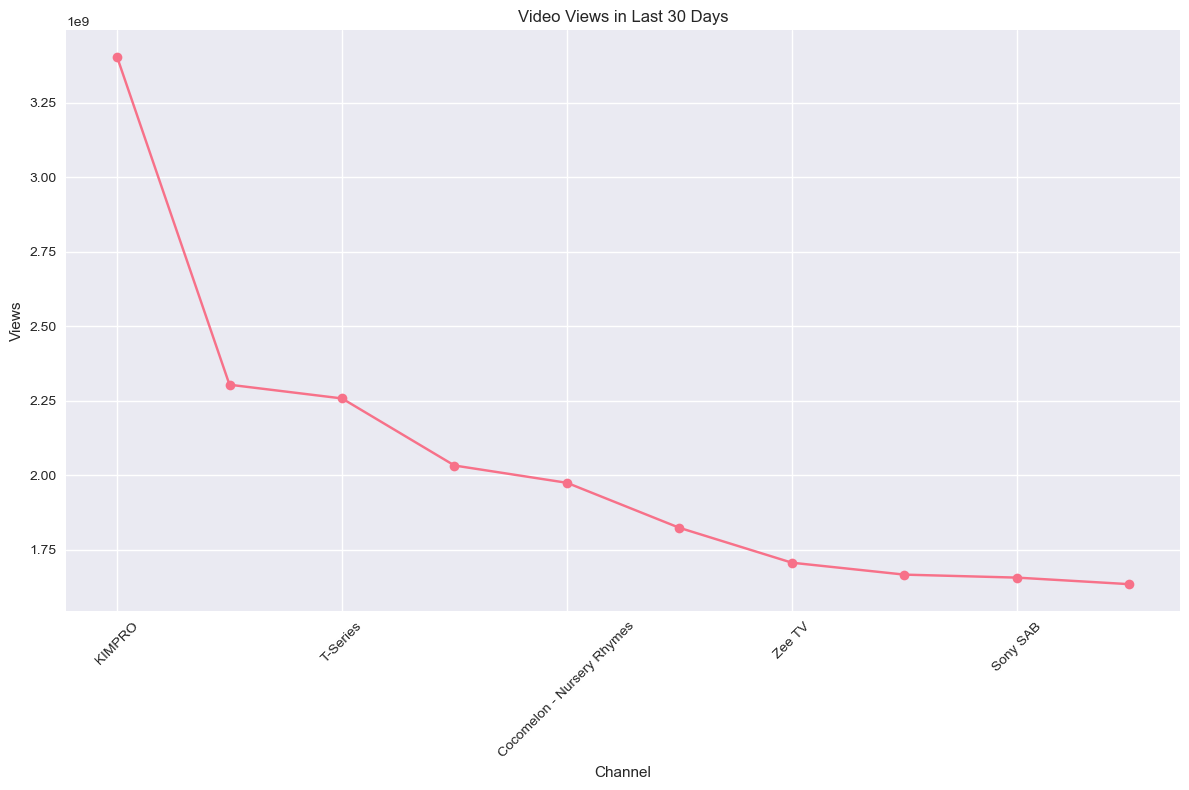

,youtuber,video_views_for_the_last_30_days
465,KIMPRO,3.404000e+09
392,DaFuq!?Boom!,2.304000e+09
0,T-Series,2.258000e+09
282,KL BRO Biju Rithvik,2.033000e+09
2,Cocomelon - Nursery Rhymes,1.975000e+09
3,SET India,1.824000e+09
17,Zee TV,1.707000e+09
130,StarPlus,1.667000e+09
12,Sony SAB,1.657000e+09
77,GR6 EXPLODE,1.635000e+09


In [77]:
# Line chart of video views in last 30 days
trending = (
    df[["youtuber", "video_views_for_the_last_30_days"]]
    .sort_values("video_views_for_the_last_30_days", ascending=False)
    .head(10)
)

ax = trending.plot(
    kind="line",
    x="youtuber",
    y="video_views_for_the_last_30_days",
    marker="o",
    figsize=(12, 8),
    legend=False,
)
ax.set_title("Video Views in Last 30 Days")
ax.set_xlabel("Channel")
ax.set_ylabel("Views")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "insight_18_views_last30_line.png", dpi=300, bbox_inches="tight")
plt.show()

trending

# Insight 19: Hubungan Upload dan Video Views (Relationship between Uploads and Video Views)

**Variables:** uploads, video views
**Tools:** Microsoft Excel
**Method:** Scatter plot
**Chart:** Scatter Plot

## Why it's interesting

To see the influence of uploads on views.

## Interpretation

Uploads have some influence on views but not always significant.

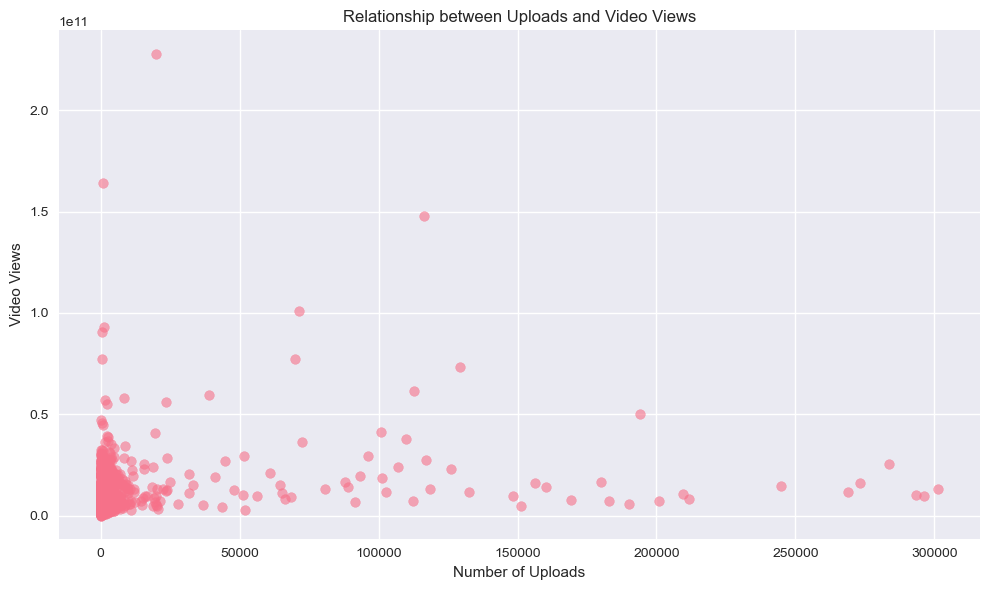

In [78]:
# Scatter plot of uploads vs video views
plt.figure(figsize=(10, 6))
plt.scatter(df["uploads"], df["video_views"], alpha=0.6)
plt.title("Relationship between Uploads and Video Views")
plt.xlabel("Number of Uploads")
plt.ylabel("Video Views")
plt.tight_layout()
plt.savefig(FIG_DIR / "insight_19_uploads_vs_views_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

# Insight 20: Negara dengan Penghasilan Channel Tertinggi (Country with Highest Channel Earnings)

**Variables:** Country, highest_yearly_earnings
**Tools:** Microsoft Excel
**Method:** SUM earnings by country
**Chart:** Bar Chart

## Why it's interesting

To see countries with the biggest digital industries.

## Interpretation

Countries with advanced digital economies have higher YouTube earnings.

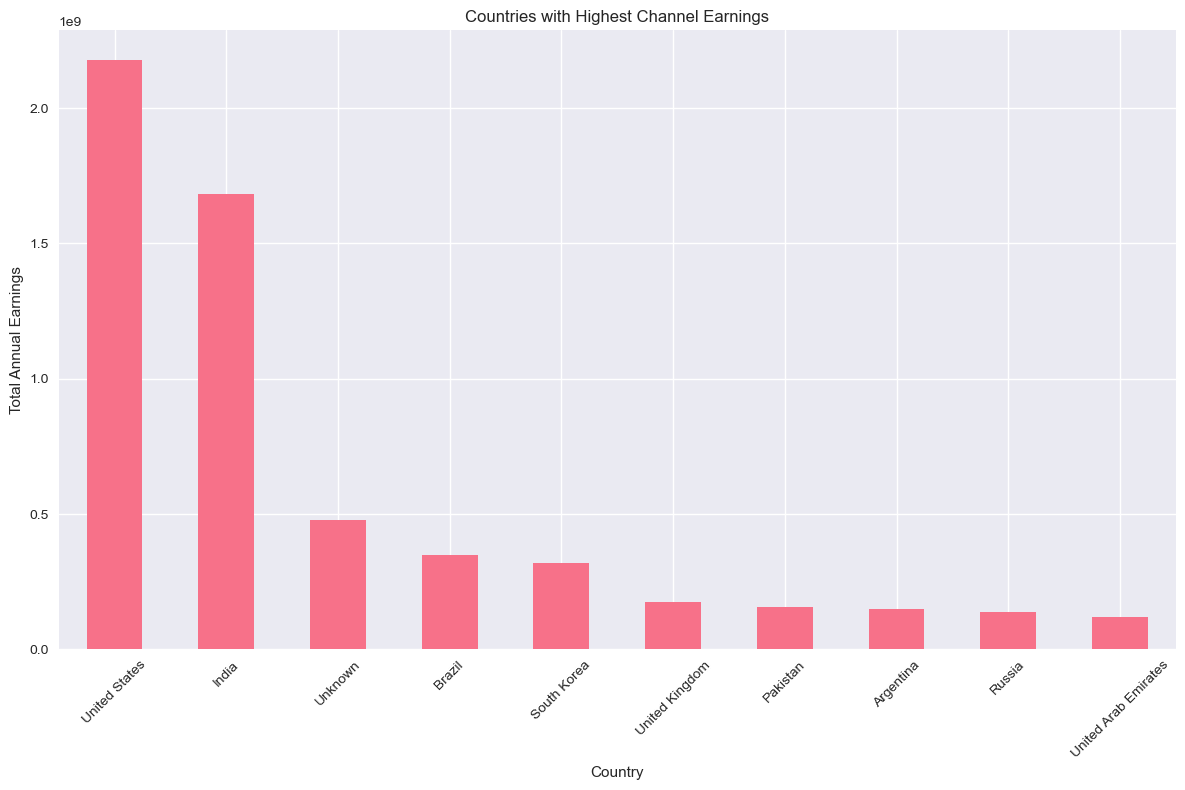

country
United States           2.178397e+09
India                   1.683354e+09
Unknown                 4.763493e+08
Brazil                  3.478070e+08
South Korea             3.202286e+08
United Kingdom          1.759100e+08
Pakistan                1.571004e+08
Argentina               1.506000e+08
Russia                  1.387213e+08
United Arab Emirates    1.213467e+08
Name: highest_yearly_earnings, dtype: float64

In [79]:
# Bar chart of total earnings by country
country_earnings = df.groupby("country")["highest_yearly_earnings"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
country_earnings.head(10).plot(kind="bar")
plt.title("Countries with Highest Channel Earnings")
plt.xlabel("Country")
plt.ylabel("Total Annual Earnings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "insight_20_total_annual_earnings_by_country_bar.png", dpi=300, bbox_inches="tight")
plt.show()

country_earnings.head(10)